In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("./train.csv")

sns.set_theme(style="whitegrid")

In [4]:
plot_df = train_df.sample(
    n=20_000,
    random_state=42
)

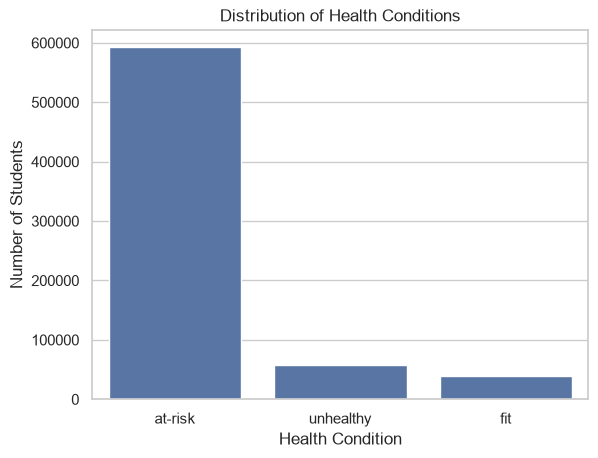

In [5]:
sns.countplot(
    data=train_df,
    x="health_condition",
    order=train_df["health_condition"].value_counts().index
)

plt.title("Distribution of Health Conditions")
plt.xlabel("Health Condition")
plt.ylabel("Number of Students")
plt.show()

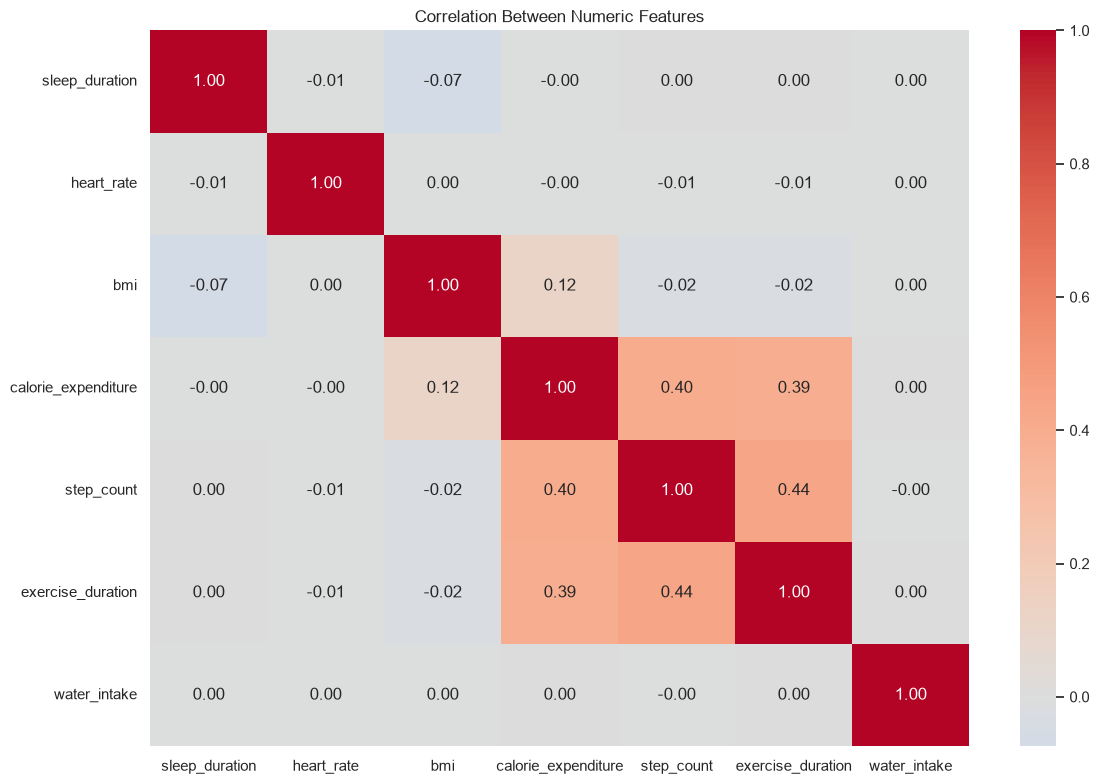

In [6]:
numeric_df = train_df.select_dtypes(include="number").drop(
    columns=["id"],
    errors="ignore"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Numeric Features")
plt.tight_layout()
plt.show()

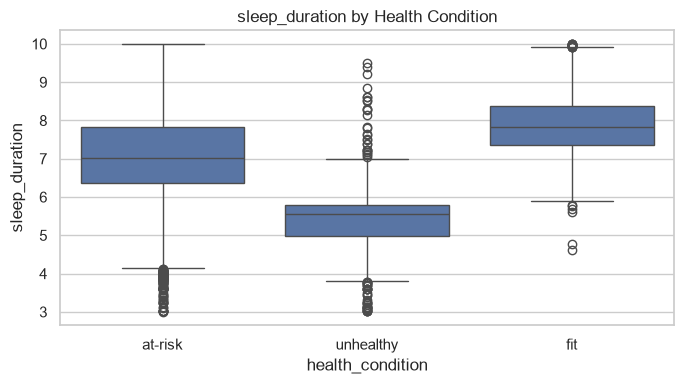

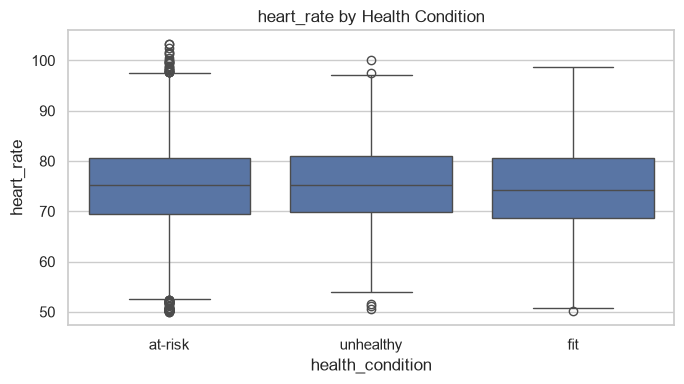

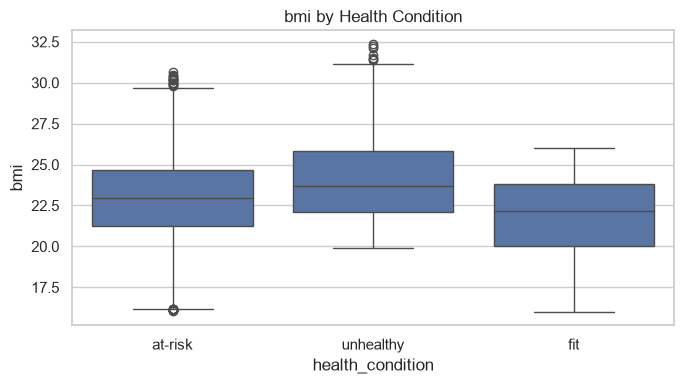

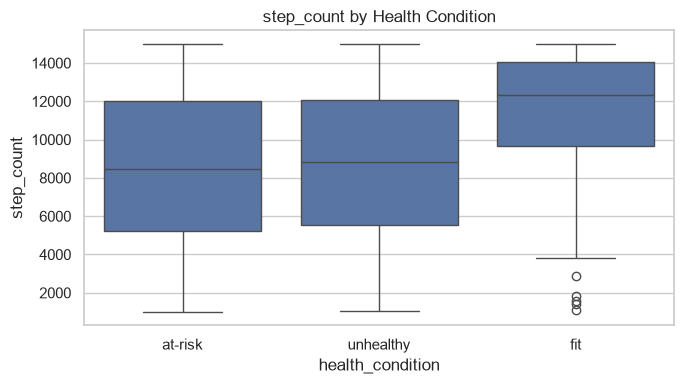

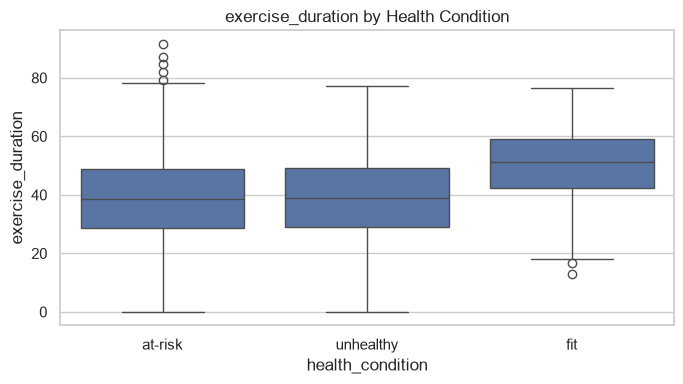

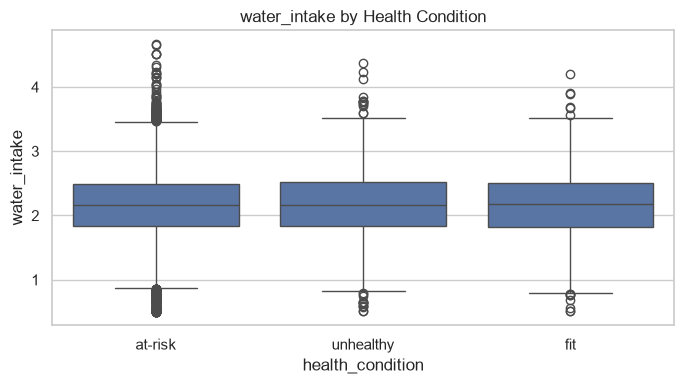

In [7]:
numeric_columns = [
    "sleep_duration",
    "heart_rate",
    "bmi",
    "step_count",
    "exercise_duration",
    "water_intake"
]

for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=plot_df,
        x="health_condition",
        y=column
    )

    plt.title(f"{column} by Health Condition")
    plt.tight_layout()
    plt.show()

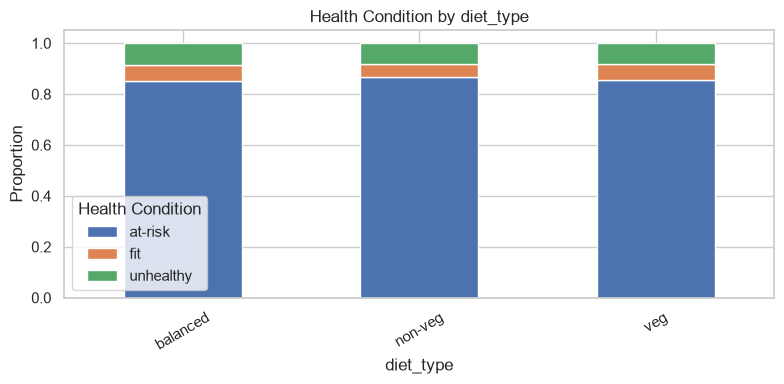

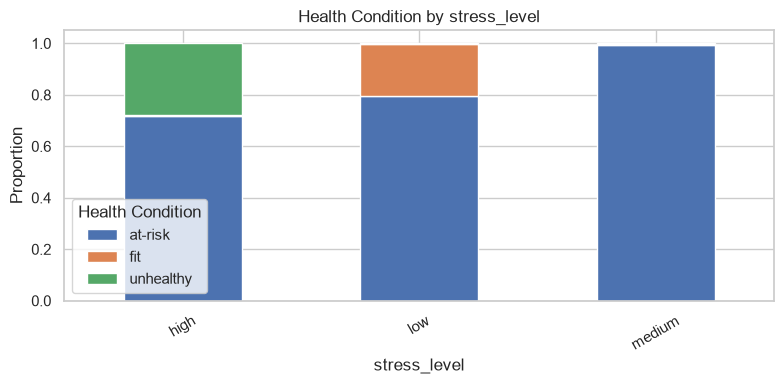

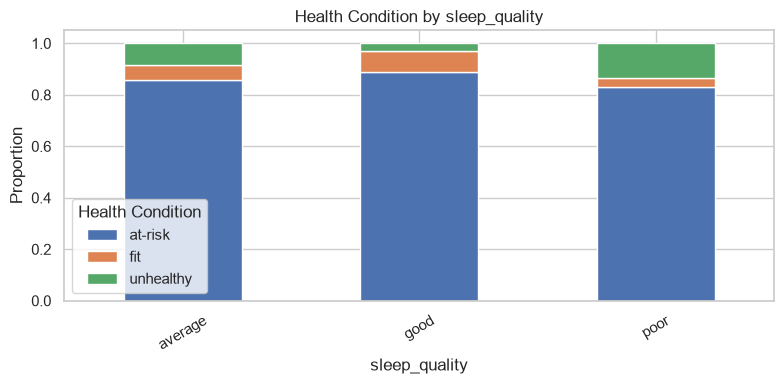

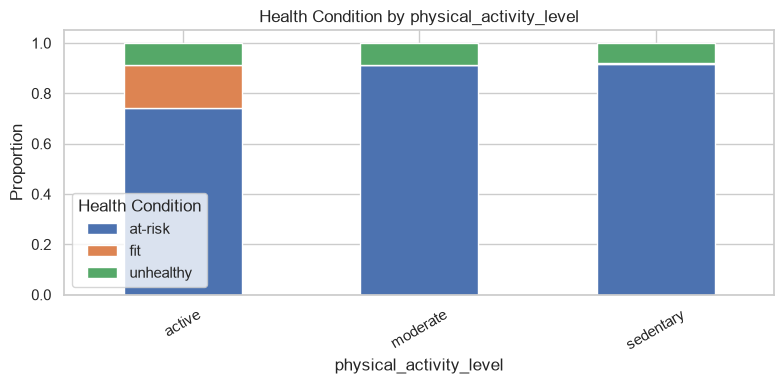

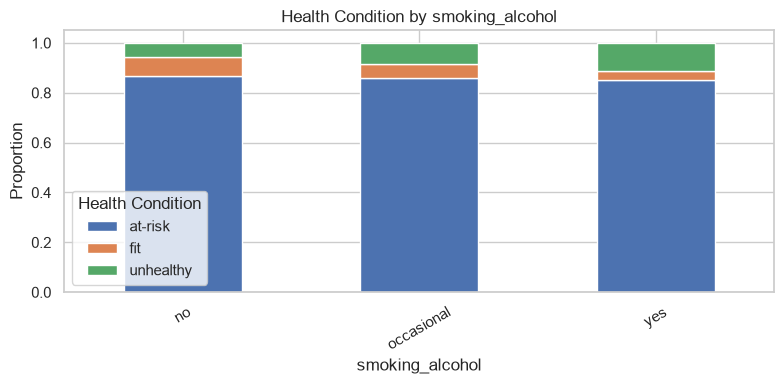

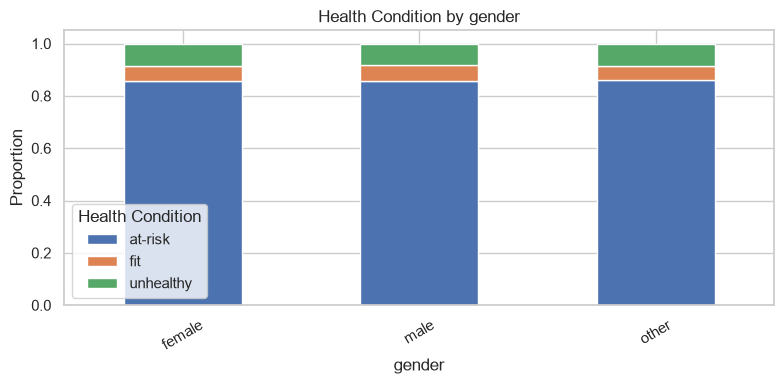

In [8]:
categorical_columns = [
    "diet_type",
    "stress_level",
    "sleep_quality",
    "physical_activity_level",
    "smoking_alcohol",
    "gender"
]

for column in categorical_columns:
    proportions = pd.crosstab(
        train_df[column],
        train_df["health_condition"],
        normalize="index"
    )

    proportions.plot(
        kind="bar",
        stacked=True,
        figsize=(8, 4)
    )

    plt.title(f"Health Condition by {column}")
    plt.xlabel(column)
    plt.ylabel("Proportion")
    plt.legend(title="Health Condition")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

                    feature  relevance
0            sleep_duration   0.153322
8              stress_level   0.143627
10  physical_activity_level   0.056559
2                       bmi   0.033346
5         exercise_duration   0.024971
4                step_count   0.020093
9             sleep_quality   0.014046
6              water_intake   0.008747
3       calorie_expenditure   0.006015
11          smoking_alcohol   0.005778
1                heart_rate   0.004156
7                 diet_type   0.000295
12                   gender   0.000126


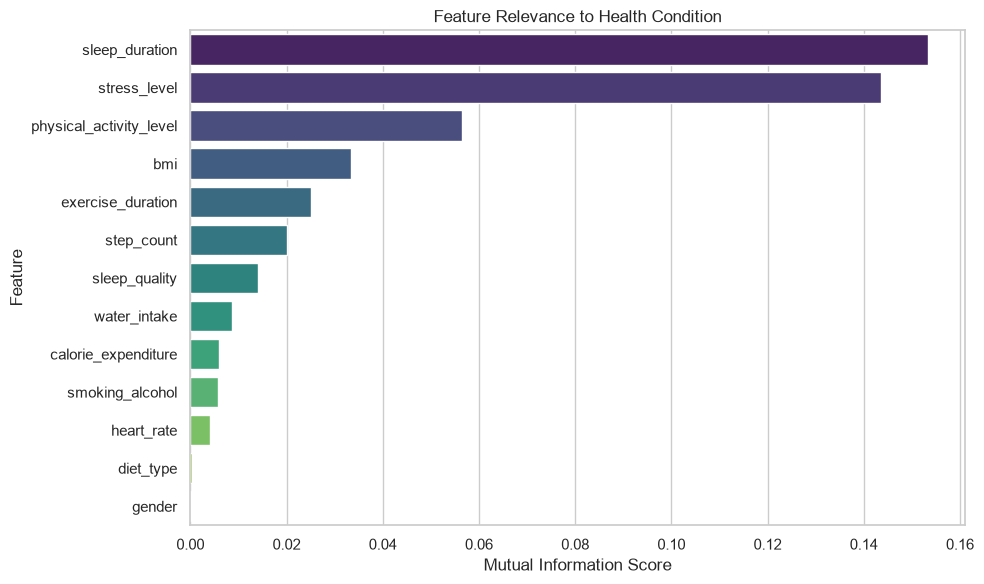

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

# Load training data
train_df = pd.read_csv("./train.csv")

# Remove rows with no target
train_df = train_df.dropna(subset=["health_condition"])

# Use a sample to make calculation faster
data = train_df.sample(
    n=min(100_000, len(train_df)),
    random_state=42
).copy()

# Separate features and target; ID is not a useful feature
X = data.drop(columns=["health_condition", "id"])
y = data["health_condition"]

categorical_columns = X.select_dtypes(exclude="number").columns
numeric_columns = X.select_dtypes(include="number").columns

# Fill missing numeric values
X[numeric_columns] = X[numeric_columns].fillna(
    X[numeric_columns].median()
)

# Convert categorical values into numeric codes
for column in categorical_columns:
    X[column] = X[column].fillna("Missing")
    X[column] = pd.factorize(X[column])[0]

# Tell sklearn which columns represent categories
discrete_features = X.columns.isin(categorical_columns)

# Calculate feature relevance
scores = mutual_info_classif(
    X,
    y,
    discrete_features=discrete_features,
    random_state=42
)

# Arrange results from most to least relevant
importance_df = pd.DataFrame({
    "feature": X.columns,
    "relevance": scores
}).sort_values("relevance", ascending=False)

print(importance_df)

# Plot the ranking
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df,
    x="relevance",
    y="feature",
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title("Feature Relevance to Health Condition")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()